# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [1]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [2]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns
import gdown


In [3]:
#Variaveis de controle
num_replys_anotados = 150
num_quotes_anotados = 150
num_originals_anotados = 100

# **Pares Tweets-Reply**

In [4]:
# baixando dataset para o collab
import gdown

file_class_caio = "1eGuTbLr6W5crwM5PKlDt8Rab1xNRUYnX"
file_class_victor = "1UueI-w33ZhSMjl4IQcI6BPqZxyi0AKji"
url_1 = f"https://drive.google.com/uc?id={file_class_caio}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor}"

gdown.download(url_1, "Cloroquina_reply_caio.csv", quiet=False)
gdown.download(url_2, "Cloroquina_reply_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1eGuTbLr6W5crwM5PKlDt8Rab1xNRUYnX
To: /content/Cloroquina_reply_caio.csv
100%|██████████| 2.37M/2.37M [00:00<00:00, 260MB/s]
Downloading...
From: https://drive.google.com/uc?id=1UueI-w33ZhSMjl4IQcI6BPqZxyi0AKji
To: /content/Cloroquina_reply_victor.csv
100%|██████████| 2.37M/2.37M [00:00<00:00, 226MB/s]


'Cloroquina_reply_victor.csv'

In [5]:
#carregando o dataset
df_caio = pd.read_csv ("Cloroquina_reply_caio.csv")
df_victor = pd.read_csv ("Cloroquina_reply_victor.csv")

In [6]:
#numero total de instancias no dataset
df_caio.shape

(7057, 4)

In [7]:
#numero total de instancias no dataset
df_victor.shape

(7057, 4)

In [8]:
df_caio.head(20)

,tweet_1,tweet_2,Class,Conflict
0,Tomo cloroquina há 16 anos. A dosagem é super-...,Vc q usa tanto tempo teve algum problema? Se f...,1,1.0
1,O divulga orientações para tratamento da Covi...,"- Ainda não existe comprovação científica, mas...",1,0.0
2,O divulga orientações para tratamento da Covi...,Nunca precisei assinar um documento depois de ...,1,0.0
3,"Trecho do termo de consentimento: ""não há, at...","""2. A Cloroquina e a hidroxicloroquina podem c...",1,0.0
4,Do no : “sabe qual minha opiniao sobre a clo...,Pq as pessoas acham que só os médicos entendem...,1,0.0
5,O divulga orientações para tratamento da Covi...,"você é um doente mental, se trata ai com cloro...",1,1.0
6,O novo protocolo amplia o uso de cloroquina e ...,Explicamos nesse fio por que não é possível di...,1,0.0
7,Porque ele quer que os brasileiros voltem ao t...,"E quando tudo estiver ""bem"". Quando tudo volta...",1,0.0
8,"Sob pressão de Bolsonaro, Ministério da Saúde ...",Conforme este Soldadestério tudo será autoriza...,1,0.0
9,"TERMO DE CONSENTIMENTO DA CLOROQUINA, OU ROLET...",... pois não há estudos demonstrando benefício...,1,0.0


In [9]:
df_victor.head(20)

,tweet_1,tweet_2,Class,Conflict
0,Tomo cloroquina há 16 anos. A dosagem é super-...,Vc q usa tanto tempo teve algum problema? Se f...,1,1.0
1,O divulga orientações para tratamento da Covi...,"- Ainda não existe comprovação científica, mas...",1,0.0
2,O divulga orientações para tratamento da Covi...,Nunca precisei assinar um documento depois de ...,1,1.0
3,"Trecho do termo de consentimento: ""não há, at...","""2. A Cloroquina e a hidroxicloroquina podem c...",1,0.0
4,Do no : “sabe qual minha opiniao sobre a clo...,Pq as pessoas acham que só os médicos entendem...,1,0.0
5,O divulga orientações para tratamento da Covi...,"você é um doente mental, se trata ai com cloro...",1,1.0
6,O novo protocolo amplia o uso de cloroquina e ...,Explicamos nesse fio por que não é possível di...,1,0.0
7,Porque ele quer que os brasileiros voltem ao t...,"E quando tudo estiver ""bem"". Quando tudo volta...",1,0.0
8,"Sob pressão de Bolsonaro, Ministério da Saúde ...",Conforme este Soldadestério tudo será autoriza...,1,0.0
9,"TERMO DE CONSENTIMENTO DA CLOROQUINA, OU ROLET...",... pois não há estudos demonstrando benefício...,1,0.0


In [10]:
df_remaining_reply = df_caio.iloc[num_replys_anotados:,:]
df_caio = df_caio.iloc[:num_replys_anotados,:]
df_victor = df_victor.iloc[:num_replys_anotados,:]

In [11]:
confusion = np.zeros((3,3))

idx_diff = []  # lista com os índices i onde as classificações diferem

In [12]:
for i in range(df_caio.shape[0]):
  caio = int(df_caio.iloc[i]["Conflict"])
  victor = int(df_victor.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff.append(i)

In [13]:
confusion

array([[63., 14.,  0.],
       [12., 61.,  0.],
       [ 0.,  0.,  0.]])

In [14]:
idx_diff

[2,
 11,
 19,
 22,
 30,
 35,
 42,
 46,
 48,
 53,
 60,
 62,
 66,
 74,
 79,
 82,
 87,
 89,
 91,
 92,
 94,
 114,
 119,
 123,
 132,
 146]

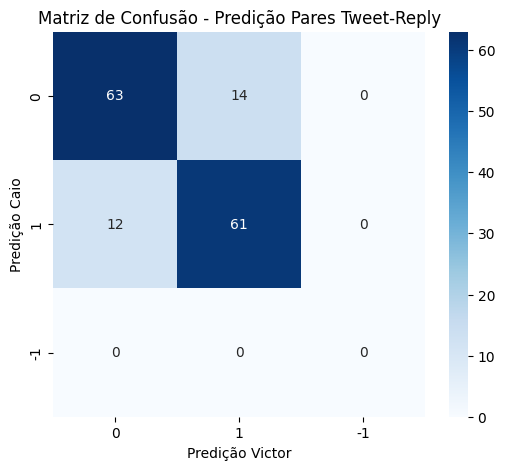

In [15]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares Tweet-Reply")
plt.show()

In [16]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff)):
  print("Tweet 1: ", df_caio.loc[idx_diff[i], "tweet_1"])
  print("Tweet 2: ", df_caio.loc[idx_diff[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio.loc[idx_diff[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor.loc[idx_diff[i], "Conflict"])])
  print()

Tweet 1:  O  divulga orientações para tratamento da Covid-19, onde a Cloroquina pode ser ministrada em casos leves, com recomendação médica e autorização do próprio paciente/família.
Tweet 2:  Nunca precisei assinar um documento depois de um médico me receitar qualquer medicamento, não parece estranho a vocês que devamos fazer isto com a cloroquina? Quer dizer, vamos tirar a responsabilidade do Presidente Jair Bolsonaro que tanto faz questão desse medicamento para nós?
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tweet 1:  Dia a dia as decisões do governo federal caem no vazio, atrapalham ou são desautorizadas. Vivemos um estado de anomia institucional ===&gt;&gt; São Paulo não mudará uso da cloroquina, diz Doria :
Tweet 2:  Cloroquina sempre foi uma opção médica (em ambiente hospitalar), o errado é usa-la POLITICAMENTE pra usar como usou " ou a vida ou a bolsa", agora é a seita da cloroquina no "posso sair se eu pegar cloroquina vai me salvar"como se ela tivesse 

In [17]:
# para contagem das divergências e convergências
sum_con = 0
sum_div = 0

In [18]:
cont_div = len(idx_diff)
cont_con = df_caio.shape[0] - cont_div

print("Divergentes: ", cont_div)
print("Convergentes: ", cont_con)

sum_div += cont_div
sum_con += cont_con

print("Total de divergentes: ", sum_div)
print("Total de convergentes: ", sum_con)

Divergentes:  26
Convergentes:  124
Total de divergentes:  26
Total de convergentes:  124


# **Pares Tweets-Quotes**

In [19]:
file_class_caio_quotes = "1VywYLyV_3Z2nq27LEpPnJYBlX6zrvExl"
file_class_victor_quotes = "1EAddUCrr7kSxL48OV5Sc3u_W5IYzIH5n"
url_1 = f"https://drive.google.com/uc?id={file_class_caio_quotes}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor_quotes}"

gdown.download(url_1, "Cloroquina_quotes_caio.csv", quiet=False)
gdown.download(url_2, "Cloroquina_quotes_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1VywYLyV_3Z2nq27LEpPnJYBlX6zrvExl
To: /content/Cloroquina_quotes_caio.csv
100%|██████████| 6.16M/6.16M [00:00<00:00, 25.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1EAddUCrr7kSxL48OV5Sc3u_W5IYzIH5n
To: /content/Cloroquina_quotes_victor.csv
100%|██████████| 6.16M/6.16M [00:00<00:00, 26.7MB/s]


'Cloroquina_quotes_victor.csv'

In [20]:
df_caio_quotes = pd.read_csv ("Cloroquina_quotes_caio.csv")
df_victor_quotes = pd.read_csv ("Cloroquina_quotes_victor.csv")

In [21]:
df_remaining_quotes = df_caio_quotes.iloc[num_quotes_anotados:,:]
df_caio_quotes = df_caio_quotes.iloc[:num_quotes_anotados,:]
df_victor_quotes = df_victor_quotes.iloc[:num_quotes_anotados,:]

In [22]:
confusion_quotes = np.zeros((3,3))


In [23]:
idx_diff_quotes = []

In [24]:
for i in range(df_caio_quotes.shape[0]):
  caio = int(df_caio_quotes.iloc[i]["Conflict"])
  victor = int(df_victor_quotes.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion_quotes[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff_quotes.append(i)


In [25]:
confusion_quotes

array([[106.,   3.,   4.],
       [  3.,  31.,   0.],
       [  2.,   1.,   0.]])

In [26]:
idx_diff_quotes

[8, 27, 36, 37, 65, 71, 80, 97, 102, 103, 112, 125, 138]

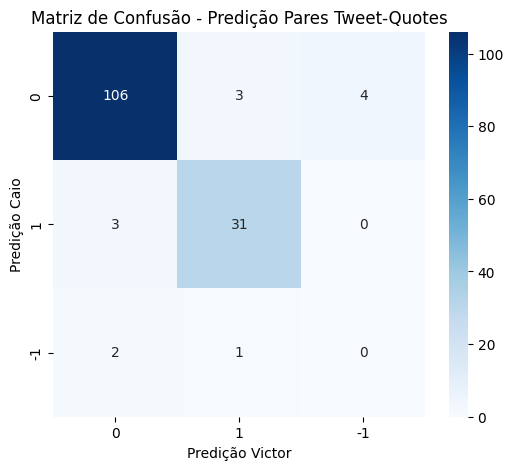

In [27]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion_quotes, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares Tweet-Quotes")
plt.show()

In [28]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff_quotes)):
  print("Tweet 1: ", df_caio_quotes.loc[idx_diff_quotes[i], "tweet_1"])
  print("Tweet 2: ", df_caio_quotes.loc[idx_diff_quotes[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio_quotes.loc[idx_diff_quotes[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor_quotes.loc[idx_diff_quotes[i], "Conflict"])])
  print()

Tweet 1:  O Prêmio para concurso de máscaras é um encontro com Michelle Bolsonaro e Damares.  Esse governo é governado por retardados.  Em breve teremos o prêmio de melhor pintura de caixa de cloroquina.  Me avise quando chegarmos ao fundo do poço!
Tweet 2:  Essa véia, é a Sílvia Abravanel do governo Bolsonaro!
Classificação Caio:  Não Conflito
Classificação Victor:  Indeterminado

Tweet 1:  Hoje  tomou uma atitude corajosa, que salvará milhares de vidas: liberou o uso da cloroquina pra todos os casos de COVID-19 no SUS, mesmo os leves  Basta o paciente autorizar o uso do medicamento, que tem se mostrado muito eficaz em diversas partes do mundo
Tweet 2:  Parece que nenhum cagão quis assinar .
Classificação Caio:  Não Conflito
Classificação Victor:  Indeterminado

Tweet 1:  Adivinha quem tá com o rab0 cheio de cachaça já na hora do almoço?  Quem é de direita acredita na cloroquina e quem é de esquerda na jararaca cretina.
Tweet 2:  Q mundo é esse que o Lula viveu? Quero saber qual é a r

In [29]:
cont_div = len(idx_diff_quotes)
cont_con = df_caio_quotes.shape[0] - cont_div

print("Divergentes: ", cont_div)
print("Convergentes: ", cont_con)

sum_div += cont_div
sum_con += cont_con

print("Total de divergentes: ", sum_div)
print("Total de convergentes: ", sum_con)

Divergentes:  13
Convergentes:  137
Total de divergentes:  39
Total de convergentes:  261


# **Pares Tweets Originals**

In [30]:
file_class_caio_originals = "1_DOy4cXZq_sSwv1ejXVCi1Yi-vsHAdjD"
file_class_victor_originals = "1pOjFWcEl94OqtA1gTFFoUUloIXFTv1jX"
url_1 = f"https://drive.google.com/uc?id={file_class_caio_originals}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor_originals}"

gdown.download(url_1, "Cloroquina_originals_caio.csv", quiet=False)
gdown.download(url_2, "Cloroquina_originals_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1_DOy4cXZq_sSwv1ejXVCi1Yi-vsHAdjD
To: /content/Cloroquina_originals_caio.csv
100%|██████████| 3.02M/3.02M [00:00<00:00, 278MB/s]
Downloading...
From: https://drive.google.com/uc?id=1pOjFWcEl94OqtA1gTFFoUUloIXFTv1jX
To: /content/Cloroquina_originals_victor.csv
100%|██████████| 3.02M/3.02M [00:00<00:00, 257MB/s]


'Cloroquina_originals_victor.csv'

In [31]:
df_caio_originals = pd.read_csv ("Cloroquina_originals_caio.csv")
df_victor_originals = pd.read_csv ("Cloroquina_originals_victor.csv")

In [32]:
df_remaining_originals = df_caio_originals.iloc[num_originals_anotados:,:]
df_caio_originals = df_caio_originals.iloc[:num_originals_anotados,:]
df_victor_originals = df_victor_originals.iloc[:num_originals_anotados,:]

In [33]:
confusion_originals = np.zeros((3,3))


In [34]:
idx_diff_originals = []

In [35]:
for i in range(df_caio_originals.shape[0]):
  caio = int(df_caio_originals.iloc[i]["Conflict"])
  victor = int(df_victor_originals.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion_originals[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff_originals.append(i)

In [36]:
confusion_originals

array([[76.,  4.,  1.],
       [ 6., 12.,  0.],
       [ 1.,  0.,  0.]])

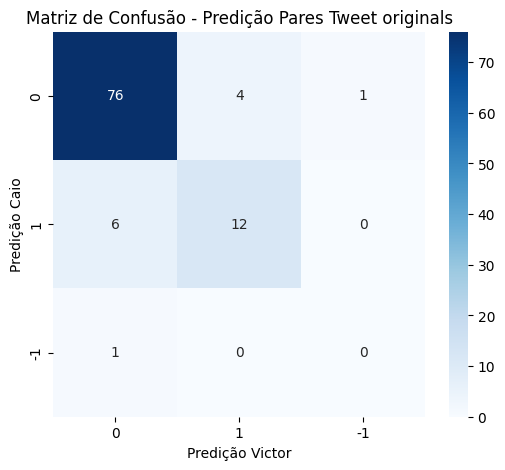

In [37]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion_originals, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares Tweet originals")
plt.show()

In [38]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff_originals)):
  print("Tweet 1: ", df_caio_originals.loc[idx_diff_originals[i], "tweet_1"])
  print("Tweet 2: ", df_caio_originals.loc[idx_diff_originals[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio_originals.loc[idx_diff_originals[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor_originals.loc[idx_diff_originals[i], "Conflict"])])
  print()

Tweet 1:  Se a mídia está contra a Cloroquina é porque é boa no combate ao vírus ...
Tweet 2:  Tinha que jogar cloroquina nos reservatórios de água
Classificação Caio:  Indeterminado
Classificação Victor:  Não Conflito

Tweet 1:  CORONAVÍRUS: Ministério da Saúde orienta uso da Cloroquina e Azitromicina para tratamento de pacientes com a Covid-19 no Brasil -  via
Tweet 2:  KKKKK CHEIRADOR D PO FALANDO Q USARIA CLOROQUINA CALA TUA BOCA SEU NOIA
Classificação Caio:  Conflito
Classificação Victor:  Não Conflito

Tweet 1:  GENTE, OLHEM QUE BOAS NOTÍCIAS!! A soja pode salvar a economia brasileira! Que o povo dance nas ruas!   #Cloroquina na Saúde e #soja na Economia! Votei!!  #SojaBrasileira #agronegocio #Economia  #EduardoBolsonaroTemRazao #VirusChines #China #CloroquinaCura
Tweet 2:  Não trate como Tubaína quem te trata como Cloroquina.
Classificação Caio:  Não Conflito
Classificação Victor:  Indeterminado

Tweet 1:  Olha o absurdo da ... A reportagem dá ênfase as "desculpas" desse bandido

In [39]:
cont_div = len(idx_diff_originals)
cont_con = df_caio_originals.shape[0] - cont_div

print("Divergentes: ", cont_div)
print("Convergentes: ", cont_con)

sum_div += cont_div
sum_con += cont_con

print("Total de divergentes: ", sum_div)
print("Total de convergentes: ", sum_con)

Divergentes:  12
Convergentes:  88
Total de divergentes:  51
Total de convergentes:  349


In [40]:
#Organizando classificações de conflitos em quotes de Caio e Victor em um unico DF
df_replys = df_caio.drop('Conflict', axis = 1)
df_replys['Conflict_Caio'] = df_caio['Conflict']
df_replys['Conflict_Victor'] = df_victor['Conflict']

In [41]:
df_replys

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,Tomo cloroquina há 16 anos. A dosagem é super-...,Vc q usa tanto tempo teve algum problema? Se f...,1,1.0,1.0
1,O divulga orientações para tratamento da Covi...,"- Ainda não existe comprovação científica, mas...",1,0.0,0.0
2,O divulga orientações para tratamento da Covi...,Nunca precisei assinar um documento depois de ...,1,0.0,1.0
3,"Trecho do termo de consentimento: ""não há, at...","""2. A Cloroquina e a hidroxicloroquina podem c...",1,0.0,0.0
4,Do no : “sabe qual minha opiniao sobre a clo...,Pq as pessoas acham que só os médicos entendem...,1,0.0,0.0
...,...,...,...,...,...
145,“Além dos graves efeitos colaterais da cloroqu...,“O empenho de Jair Bolsonaro para ampliar o us...,1,0.0,0.0
146,OMS: hidroxicloroquina ou cloroquina até agora...,Mas está salvando vidas. Enquanto a ciência ma...,1,1.0,0.0
147,"- Ainda não existe comprovação científica, mas...","a cala boca seu merda, enche o teu cu de cloro...",1,1.0,1.0
148,Caiu na rede: Cloroquina com feijão,Pros direitões cloroquina com feijão... Nois d...,1,0.0,0.0


In [42]:
#Organizando classificações de conflitos em quotes de Caio e Victor em um unico DF
df_quotes = df_caio_quotes.drop('Conflict',axis=1)
df_quotes['Conflict_Caio'] = df_caio_quotes['Conflict']
df_quotes['Conflict_Victor'] = df_victor_quotes['Conflict']

In [43]:
df_quotes

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,O divulga orientações para tratamento da Covi...,Agora é oficial!!! Vamos de novo: Melhor ter u...,2,0.0,0.0
1,Qual é a cloroquina da sua profissão?,"""tem um conhecido meu que é adEvogado e disse ...",2,0.0,0.0
2,"- Ainda não existe comprovação científica, mas...",Precisamos superar o debate político sobre a c...,2,0.0,0.0
3,"- Ainda não existe comprovação científica, mas...",“Pior do que ser derrotado é a vergonha de não...,2,0.0,0.0
4,Cloroquina 'une' Bolsonaro e Maduro em meio à ...,"""é do levante, tá com Maduro!""",2,0.0,0.0
...,...,...,...,...,...
145,"Diante da recusa de dois ministros da Saúde, q...",E agora comunistas de M. Ameacem o GENERAL PAZ...,2,0.0,0.0
146,“Ainda bem que a natureza criou esse monstro c...,Ai não dar pra defender né Lulinha,2,0.0,0.0
147,#JornalHoje a cloroquina é usada no Amazonas à...,A Globo lixo manipulando,2,0.0,0.0
148,Bolsonaro admite que não há comprovação cientí...,E fica enchendo o saco por quê?,2,0.0,0.0


In [44]:
#Organizando classificações de conflitos em originals de Caio e Victor em um unico DF
df_originals = df_caio_originals.drop('Conflict',axis=1)
df_originals['Conflict_Caio'] = df_caio_originals['Conflict']
df_originals['Conflict_Victor'] = df_victor_originals['Conflict']

In [45]:
df_originals

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,(Hidroxi)Cloroquina: quem precisar e avaliar (...,Não existe comprovação científica sobre a efic...,0,1.0,1.0
1,"E ssa gente querendo cancelar o Lula, só pq el...","acaba de dizer em rede nacional que a Aspen, u...",0,0.0,0.0
2,Se a mídia está contra a Cloroquina é porque é...,Tinha que jogar cloroquina nos reservatórios d...,0,-1.0,0.0
3,Bora dropar cloroquina pra ficar doidão,Assim como o ateu deixa de ser ateu quando pre...,0,0.0,0.0
4,CORONAVÍRUS: Ministério da Saúde orienta uso d...,KKKKK CHEIRADOR D PO FALANDO Q USARIA CLOROQUI...,0,1.0,0.0
...,...,...,...,...,...
95,Dia lindo pra mandar bolsominion enfiar cloroq...,acelera,0,0.0,0.0
96,Lendo um artigo da Nature sobre a Cloroquina e...,Uso da cloroquina dependerá de médico e pacien...,0,0.0,0.0
97,"É gado pobre e ""crasse mérdia"": Com redução de...",rsrsrsrs,0,0.0,0.0
98,Vi que uma mulher disse pra fazer a vacina com...,Se já estão registrando mortes aleatórias como...,0,0.0,0.0


In [46]:
#concatenando os datasets parciais:
df_cloroquina_classificado = pd.concat([df_originals, df_replys, df_quotes], ignore_index=True, axis = 0)
df_cloroquina_classificado

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,(Hidroxi)Cloroquina: quem precisar e avaliar (...,Não existe comprovação científica sobre a efic...,0,1.0,1.0
1,"E ssa gente querendo cancelar o Lula, só pq el...","acaba de dizer em rede nacional que a Aspen, u...",0,0.0,0.0
2,Se a mídia está contra a Cloroquina é porque é...,Tinha que jogar cloroquina nos reservatórios d...,0,-1.0,0.0
3,Bora dropar cloroquina pra ficar doidão,Assim como o ateu deixa de ser ateu quando pre...,0,0.0,0.0
4,CORONAVÍRUS: Ministério da Saúde orienta uso d...,KKKKK CHEIRADOR D PO FALANDO Q USARIA CLOROQUI...,0,1.0,0.0
...,...,...,...,...,...
395,"Diante da recusa de dois ministros da Saúde, q...",E agora comunistas de M. Ameacem o GENERAL PAZ...,2,0.0,0.0
396,“Ainda bem que a natureza criou esse monstro c...,Ai não dar pra defender né Lulinha,2,0.0,0.0
397,#JornalHoje a cloroquina é usada no Amazonas à...,A Globo lixo manipulando,2,0.0,0.0
398,Bolsonaro admite que não há comprovação cientí...,E fica enchendo o saco por quê?,2,0.0,0.0


In [47]:
df_cloroquina_classificado.to_csv("cloroquina_classificado.csv", index=False, encoding="utf-8")
files.download("cloroquina_classificado.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das divergencias**

In [48]:
div_reply = df_caio.iloc[idx_diff].drop('Conflict', axis=1)
div_reply['Conflict_caio'] = df_caio['Conflict'].iloc[idx_diff].astype(int)
div_reply['Conflict_victor'] = df_victor['Conflict'].iloc[idx_diff].astype(int)
div_reply['Conflict'] = np.nan
div_quotes = df_caio_quotes.iloc[idx_diff_quotes].drop('Conflict', axis=1)
div_quotes['Conflict_caio'] = df_caio_quotes['Conflict'].iloc[idx_diff_quotes].astype(int)
div_quotes['Conflict_victor'] = df_victor_quotes['Conflict'].iloc[idx_diff_quotes].astype(int)
div_quotes['Conflict'] = np.nan
div_originals = df_caio_originals.iloc[idx_diff_originals].drop('Conflict', axis=1)
div_originals['Conflict_caio'] = df_caio_originals['Conflict'].iloc[idx_diff_originals].astype(int)
div_originals['Conflict_victor'] = df_victor_originals['Conflict'].iloc[idx_diff_originals].astype(int)
div_originals['Conflict'] = np.nan

In [49]:
div_reply.shape

(26, 6)

In [50]:
div_quotes.shape

(13, 6)

In [51]:
div_originals.shape

(12, 6)

In [52]:
div_cloroquina = pd.concat([div_originals, div_reply, div_quotes], ignore_index=True, axis = 0)

In [53]:
div_cloroquina.shape

(51, 6)

In [54]:
div_cloroquina_final = div_cloroquina.drop(columns=['Conflict_caio', 'Conflict_victor'])
div_cloroquina_final

,tweet_1,tweet_2,Class,Conflict
0,Se a mídia está contra a Cloroquina é porque é...,Tinha que jogar cloroquina nos reservatórios d...,0,NaN
1,CORONAVÍRUS: Ministério da Saúde orienta uso d...,KKKKK CHEIRADOR D PO FALANDO Q USARIA CLOROQUI...,0,NaN
2,"GENTE, OLHEM QUE BOAS NOTÍCIAS!! A soja pode s...",Não trate como Tubaína quem te trata como Clor...,0,NaN
3,Olha o absurdo da ... A reportagem dá ênfase a...,A vontade é mandar essas veia tudo enfiar a Cl...,0,NaN
4,"Todo mundo já sabe o que vai acontecer, né? Na...","Esse twitter tá uma loucura, gente com nude va...",0,NaN
5,DENUNCIEM TUDO QUE ESSE GOVERNO INVENTAR DE ME...,Tiago só se fala em cloroquina porque na práti...,0,NaN
6,a galera tem que cair na real que o lance do g...,#JornalNacional Então o Brasil achou a CURA pa...,0,NaN
7,dei um espirro aqui acho melhor tomar essa clo...,O Trump é um louco. Tomou Cloroquina sem consu...,0,NaN
8,minha ex orientadora &gt;farmaceutica&lt; bols...,"cloroquina, cloroquina, cloroquina tem no sus ...",0,NaN
9,"Boa noite pra quem é Tubaína, pra quem é cloro...",A cloroquina usada no começo do tratamento do ...,0,NaN


In [55]:
div_cloroquina_final.to_csv("divergencias_cloroquina.csv", index=False, encoding="utf-8")
files.download("divergencias_cloroquina.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das Convergencias**


In [56]:
conv_reply = df_caio.drop(index=idx_diff, errors='ignore')
conv_quotes = df_caio_quotes.drop(index=idx_diff_quotes, errors='ignore')
conv_originals = df_caio_originals.drop(index=idx_diff_originals, errors='ignore')

In [57]:
conv_reply.shape

(124, 4)

In [58]:
conv_cloroquina = pd.concat([conv_originals, conv_reply, conv_quotes], ignore_index=True, axis = 0)

In [59]:
conv_cloroquina

,tweet_1,tweet_2,Class,Conflict
0,(Hidroxi)Cloroquina: quem precisar e avaliar (...,Não existe comprovação científica sobre a efic...,0,1.0
1,"E ssa gente querendo cancelar o Lula, só pq el...","acaba de dizer em rede nacional que a Aspen, u...",0,0.0
2,Bora dropar cloroquina pra ficar doidão,Assim como o ateu deixa de ser ateu quando pre...,0,0.0
3,Segundo fight com o papai por causa da CLOROQU...,As novas orientações para tratamento da Covid-...,0,0.0
4,Mas já??? Acabou de liberar a cloroquina hj e...,"Lula, num ato falho,diz ""ainda bem"" pra COVID....",0,0.0
...,...,...,...,...
344,"Diante da recusa de dois ministros da Saúde, q...",E agora comunistas de M. Ameacem o GENERAL PAZ...,2,0.0
345,“Ainda bem que a natureza criou esse monstro c...,Ai não dar pra defender né Lulinha,2,0.0
346,#JornalHoje a cloroquina é usada no Amazonas à...,A Globo lixo manipulando,2,0.0
347,Bolsonaro admite que não há comprovação cientí...,E fica enchendo o saco por quê?,2,0.0


In [60]:
#adicionando as classificações do professor
file_class_cloroquina_prof = "1Bq2hdrKkvlp63uBMpzY3M1BF3XdmUpCu"
url = f"https://drive.google.com/uc?id={file_class_cloroquina_prof}"
gdown.download(url, "cloroquina_class_prof.csv", quiet=False)
df_class_prof = pd.read_csv ("cloroquina_class_prof.csv")

Downloading...
From: https://drive.google.com/uc?id=1Bq2hdrKkvlp63uBMpzY3M1BF3XdmUpCu
To: /content/cloroquina_class_prof.csv
100%|██████████| 13.6k/13.6k [00:00<00:00, 20.9MB/s]


In [61]:
df_class_prof

,tweet_1,tweet_2,Class,Conflict
0,Se a mídia está contra a Cloroquina é porque é...,Tinha que jogar cloroquina nos reservatórios d...,0,0
1,CORONAVÍRUS: Ministério da Saúde orienta uso d...,KKKKK CHEIRADOR D PO FALANDO Q USARIA CLOROQUI...,0,0
2,"GENTE, OLHEM QUE BOAS NOTÍCIAS!! A soja pode s...",Não trate como Tubaína quem te trata como Clor...,0,-1
3,Olha o absurdo da ... A reportagem dá ênfase a...,A vontade é mandar essas veia tudo enfiar a Cl...,0,1
4,"Todo mundo já sabe o que vai acontecer, né? Na...","Esse twitter tá uma loucura, gente com nude va...",0,0
5,DENUNCIEM TUDO QUE ESSE GOVERNO INVENTAR DE ME...,Tiago só se fala em cloroquina porque na práti...,0,1
6,a galera tem que cair na real que o lance do g...,#JornalNacional Então o Brasil achou a CURA pa...,0,0
7,dei um espirro aqui acho melhor tomar essa clo...,O Trump é um louco. Tomou Cloroquina sem consu...,0,1
8,minha ex orientadora &gt;farmaceutica&lt; bols...,"cloroquina, cloroquina, cloroquina tem no sus ...",0,-1
9,"Boa noite pra quem é Tubaína, pra quem é cloro...",A cloroquina usada no começo do tratamento do ...,0,1


In [62]:
df_desempate = div_cloroquina.merge(df_class_prof, on=['tweet_1', 'tweet_2'], how='inner')
df_desempate = df_desempate.drop(columns=['Conflict_x', 'Class_y'])
df_desempate = df_desempate.rename(columns={'Class_x': 'Class', 'Conflict_y': 'Conflict_prof'})
df_desempate

,tweet_1,tweet_2,Class,Conflict_caio,Conflict_victor,Conflict_prof
0,Se a mídia está contra a Cloroquina é porque é...,Tinha que jogar cloroquina nos reservatórios d...,0,-1,0,0
1,CORONAVÍRUS: Ministério da Saúde orienta uso d...,KKKKK CHEIRADOR D PO FALANDO Q USARIA CLOROQUI...,0,1,0,0
2,"GENTE, OLHEM QUE BOAS NOTÍCIAS!! A soja pode s...",Não trate como Tubaína quem te trata como Clor...,0,0,-1,-1
3,Olha o absurdo da ... A reportagem dá ênfase a...,A vontade é mandar essas veia tudo enfiar a Cl...,0,0,1,1
4,"Todo mundo já sabe o que vai acontecer, né? Na...","Esse twitter tá uma loucura, gente com nude va...",0,0,1,0
5,DENUNCIEM TUDO QUE ESSE GOVERNO INVENTAR DE ME...,Tiago só se fala em cloroquina porque na práti...,0,1,0,1
6,a galera tem que cair na real que o lance do g...,#JornalNacional Então o Brasil achou a CURA pa...,0,0,1,0
7,dei um espirro aqui acho melhor tomar essa clo...,O Trump é um louco. Tomou Cloroquina sem consu...,0,1,0,1
8,minha ex orientadora &gt;farmaceutica&lt; bols...,"cloroquina, cloroquina, cloroquina tem no sus ...",0,1,0,-1
9,"Boa noite pra quem é Tubaína, pra quem é cloro...",A cloroquina usada no começo do tratamento do ...,0,1,0,1


In [63]:
def resolver_conflito(row):
    prof = row['Conflict_prof']
    caio = row['Conflict_caio']
    victor = row['Conflict_victor']

    if prof == caio or prof == victor:
        return prof
    else:
        return -1

df_desempate['Conflict'] = df_desempate.apply(resolver_conflito, axis=1)

In [64]:
df_desempate

,tweet_1,tweet_2,Class,Conflict_caio,Conflict_victor,Conflict_prof,Conflict
0,Se a mídia está contra a Cloroquina é porque é...,Tinha que jogar cloroquina nos reservatórios d...,0,-1,0,0,0
1,CORONAVÍRUS: Ministério da Saúde orienta uso d...,KKKKK CHEIRADOR D PO FALANDO Q USARIA CLOROQUI...,0,1,0,0,0
2,"GENTE, OLHEM QUE BOAS NOTÍCIAS!! A soja pode s...",Não trate como Tubaína quem te trata como Clor...,0,0,-1,-1,-1
3,Olha o absurdo da ... A reportagem dá ênfase a...,A vontade é mandar essas veia tudo enfiar a Cl...,0,0,1,1,1
4,"Todo mundo já sabe o que vai acontecer, né? Na...","Esse twitter tá uma loucura, gente com nude va...",0,0,1,0,0
5,DENUNCIEM TUDO QUE ESSE GOVERNO INVENTAR DE ME...,Tiago só se fala em cloroquina porque na práti...,0,1,0,1,1
6,a galera tem que cair na real que o lance do g...,#JornalNacional Então o Brasil achou a CURA pa...,0,0,1,0,0
7,dei um espirro aqui acho melhor tomar essa clo...,O Trump é um louco. Tomou Cloroquina sem consu...,0,1,0,1,1
8,minha ex orientadora &gt;farmaceutica&lt; bols...,"cloroquina, cloroquina, cloroquina tem no sus ...",0,1,0,-1,-1
9,"Boa noite pra quem é Tubaína, pra quem é cloro...",A cloroquina usada no começo do tratamento do ...,0,1,0,1,1


In [65]:
df_desempate = df_desempate.drop(columns=['Conflict_caio', 'Conflict_victor', 'Conflict_prof'])
df_desempate

,tweet_1,tweet_2,Class,Conflict
0,Se a mídia está contra a Cloroquina é porque é...,Tinha que jogar cloroquina nos reservatórios d...,0,0
1,CORONAVÍRUS: Ministério da Saúde orienta uso d...,KKKKK CHEIRADOR D PO FALANDO Q USARIA CLOROQUI...,0,0
2,"GENTE, OLHEM QUE BOAS NOTÍCIAS!! A soja pode s...",Não trate como Tubaína quem te trata como Clor...,0,-1
3,Olha o absurdo da ... A reportagem dá ênfase a...,A vontade é mandar essas veia tudo enfiar a Cl...,0,1
4,"Todo mundo já sabe o que vai acontecer, né? Na...","Esse twitter tá uma loucura, gente com nude va...",0,0
5,DENUNCIEM TUDO QUE ESSE GOVERNO INVENTAR DE ME...,Tiago só se fala em cloroquina porque na práti...,0,1
6,a galera tem que cair na real que o lance do g...,#JornalNacional Então o Brasil achou a CURA pa...,0,0
7,dei um espirro aqui acho melhor tomar essa clo...,O Trump é um louco. Tomou Cloroquina sem consu...,0,1
8,minha ex orientadora &gt;farmaceutica&lt; bols...,"cloroquina, cloroquina, cloroquina tem no sus ...",0,-1
9,"Boa noite pra quem é Tubaína, pra quem é cloro...",A cloroquina usada no começo do tratamento do ...,0,1


In [66]:
conv_cloroquina = pd.concat([conv_cloroquina, df_desempate], ignore_index=True, axis = 0)
conv_cloroquina

,tweet_1,tweet_2,Class,Conflict
0,(Hidroxi)Cloroquina: quem precisar e avaliar (...,Não existe comprovação científica sobre a efic...,0,1.0
1,"E ssa gente querendo cancelar o Lula, só pq el...","acaba de dizer em rede nacional que a Aspen, u...",0,0.0
2,Bora dropar cloroquina pra ficar doidão,Assim como o ateu deixa de ser ateu quando pre...,0,0.0
3,Segundo fight com o papai por causa da CLOROQU...,As novas orientações para tratamento da Covid-...,0,0.0
4,Mas já??? Acabou de liberar a cloroquina hj e...,"Lula, num ato falho,diz ""ainda bem"" pra COVID....",0,0.0
...,...,...,...,...
385,Será que robô entende quando xingamos ele? Hoo...,Nem perca seu tempo com essa gentalha ! Olha o...,2,0.0
386,Vc tomaria a Cloroquina?,Quem tem que dizer se eu deveria tomar ou não ...,2,0.0
387,"Hoje tomou uma atitude corajosa, que salvará ...",eu queria dizer q tenho pena de pessoas que tã...,2,1.0
388,Dia a dia as decisões do governo federal caem ...,”Jornalismo Profissional” O que tem que expli...,2,1.0


In [67]:
conv_cloroquina.to_csv("convergencias_cloroquina.csv", index=False, encoding="utf-8")
files.download("convergencias_cloroquina.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Dataset com pares não anotados**

In [68]:
remainig_df = pd.concat([df_remaining_originals, df_remaining_reply, df_remaining_quotes], ignore_index=True, axis = 0)
remainig_df = remainig_df.drop('Conflict', axis=1)
remainig_df

,tweet_1,tweet_2,Class
0,"então gente, vocês vão tomar cloroquina ou com...","Cloroquina, Seja a minha desculpa ou só minha ...",0
1,"Em entrevista à , Olavo de Carvalho questiona ...",Velho ..... Se essa bosta de cloroquina servic...,0
2,Já seria uma tragédia se “só quem é de direita...,cloroquina de cú é rola,0
3,Se alguém falar que a cloroquina salvou a Aust...,"É tão legal ver gente liberal, progressista e ...",0
4,AMB: nova regra para cloroquina 'preserva médi...,Não dá pra entender com criticar pq fala só ...,0
...,...,...,...
44702,"Em entrevista à , Olavo de Carvalho questiona ...",A galera da ibope pra esse loco pqp,2
44703,Qual é a cloroquina da sua profissão?,formulário socioeconômico,2
44704,"Militares já produziram 1,2 milhão de comprimi...",Quero ver quem me diz agora que isso não é lob...,2
44705,Apresentei um projeto de decreto legislativo p...,Acho bom e vc ficar quieto. Já já pegam seus p...,2


In [69]:
remainig_df.to_csv("cloroquina_nao_anotado.csv", index=False, encoding="utf-8")
files.download("cloroquina_nao_anotado.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>